In [15]:
from pyNOMIC import combine, chop_correction, subtract_background, frame_registration, frame_evaluation, frame_rejection
import shutil, pathlib
import numpy as np

raw_dir = r"C:\Users\mmc\Music\Project\Vega\raw"
master_badmap_dir = r"C:\Users\mmc\Music\Project\master_badmap.fits"
obj='vega'
'''
uncorrected_files, chops, frame_medians, highpass_dir = combine(obj, raw_dir, master_badmap_dir, 0, "left", testing=True,\
                                                           test_number=1000, start_frame=30000)
files, chops = chop_correction(uncorrected_files, highpass_dir, chops)
subtracted_dir = subtract_background(files, raw_dir)
shutil.rmtree(highpass_dir)
psfmaxima, background_dev, reffit, array_shape, file_size, aligned_dir = frame_registration(files, subtracted_dir)
shutil.rmtree(subtracted_dir)
fwhms, eccentricities, correlations, amplitudes, gauss_offsets = frame_evaluation(files, chops, aligned_dir, array_shape, file_size)
frame_bool = frame_rejection(psfmaxima, background_dev, fwhms, eccentricities, correlations, amplitudes, gauss_offsets)

aligned_files = np.asarray(list(pathlib.Path(str(aligned_dir)).rglob('*.fits')))

np.savez(obj+"_NOMIC_reduced.npz",aligned_dir, aligned_files, chops, array_shape,\
         file_size, psfmaxima, background_dev, reffit, fwhms, eccentricities, correlations, amplitudes, gauss_offsets, frame_bool)
'''
print("Files saved")

Searching in  C:\Users\mmc\Music\Project\Vega\raw
Detected  42667  fits files
Start frame = 30000
New file count =  1000
Reading file headers and creating high pass filtered frames...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.37it/s]


Finding chop positions....


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:28<00:00, 35.13it/s]


Finding consecutive repeat chop positions...


...

Subtracting backgrounds....


100%|████████████████████████████████████████████████████████████████████████████████| 824/824 [00:42<00:00, 19.28it/s]


Aligning frames....


100%|████████████████████████████████████████████████████████████████████████████████| 822/822 [00:37<00:00, 22.17it/s]
integrating files: 1it [00:09,  9.02s/it]
integrating files: 1it [00:09,  9.06s/it]
100%|████████████████████████████████████████████████████████████████████████████████| 824/824 [00:37<00:00, 21.79it/s]

Files saved


In [19]:
reduced_data = np.load(obj+"_NOMIC_reduced.npz", allow_pickle=True)
aligned_dir = reduced_data["arr_0"]
aligned_files = reduced_data["arr_1"]
chops = reduced_data["arr_2"]
array_shape = reduced_data["arr_3"]
file_size = reduced_data["arr_4"]
psfmaxima = reduced_data["arr_5"]
background_dev = reduced_data["arr_6"]
reffit = reduced_data["arr_7"]
fwhms = reduced_data["arr_8"]
eccentricities = reduced_data["arr_9"]
correlations = reduced_data["arr_10"]
amplitudes = reduced_data["arr_11"]
gauss_offsets = reduced_data["arr_12"]
frame_bool = reduced_data["arr_13"]

psfmaxima = psfmaxima/np.mean(psfmaxima)
amplitudes = amplitudes/np.mean(amplitudes)
correlations = correlations/np.mean(correlations)


In [20]:
sigma = 1.5
'''
gauss_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (amplitudes > np.median(amplitudes) - sigma*np.std(amplitudes)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) 
'''
ecc_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (amplitudes > np.median(amplitudes) - sigma*np.std(amplitudes)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) #&\
        #(gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))

fwhms_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (amplitudes > np.median(amplitudes) - sigma*np.std(amplitudes)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) &\
        (gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))
'''
amps_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) &\
        (gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))
'''
corr_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) &\
        (gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))
'''
psfmax_bool = (background_dev < np.median(background_dev) + sigma*np.std(background_dev)) &\
        (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (amplitudes > np.median(amplitudes) - sigma*np.std(amplitudes)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) &\
        (gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))
'''
back_bool = (psfmaxima > np.median(psfmaxima) - sigma*np.std(psfmaxima)) &\
        (correlations > np.median(correlations) - sigma*np.std(correlations)) &\
        (amplitudes > np.median(amplitudes) - sigma*np.std(amplitudes)) &\
        (fwhms < np.median(fwhms) + sigma*np.std(fwhms)) &\
        (eccentricities < np.median(eccentricities) + sigma*np.std(eccentricities)) &\
        (gauss_offsets < np.median(gauss_offsets) + sigma*np.std(gauss_offsets))


#print("No gaussians:", len(gauss_bool[gauss_bool]))
print("No eccentricities:", len(ecc_bool[ecc_bool]))
print("No fwhms:", len(fwhms_bool[fwhms_bool]))
#print("No amplitudes:", len(amps_bool[amps_bool]))
print("No correlation:", len(corr_bool[corr_bool]))
#print("No psfmax:", len(psfmax_bool[psfmax_bool]))
print("No background_dev:", len(back_bool[back_bool]))
print("All:", len(frame_bool[frame_bool]))

print(correlations[frame_bool ^ fwhms_bool])
print( np.median(correlations) - sigma*np.std(correlations))

No eccentricities: 784
No fwhms: 701
No correlation: 699
No background_dev: 699
All: 699
[0.71021772 0.23836951]
-4.12432244624012


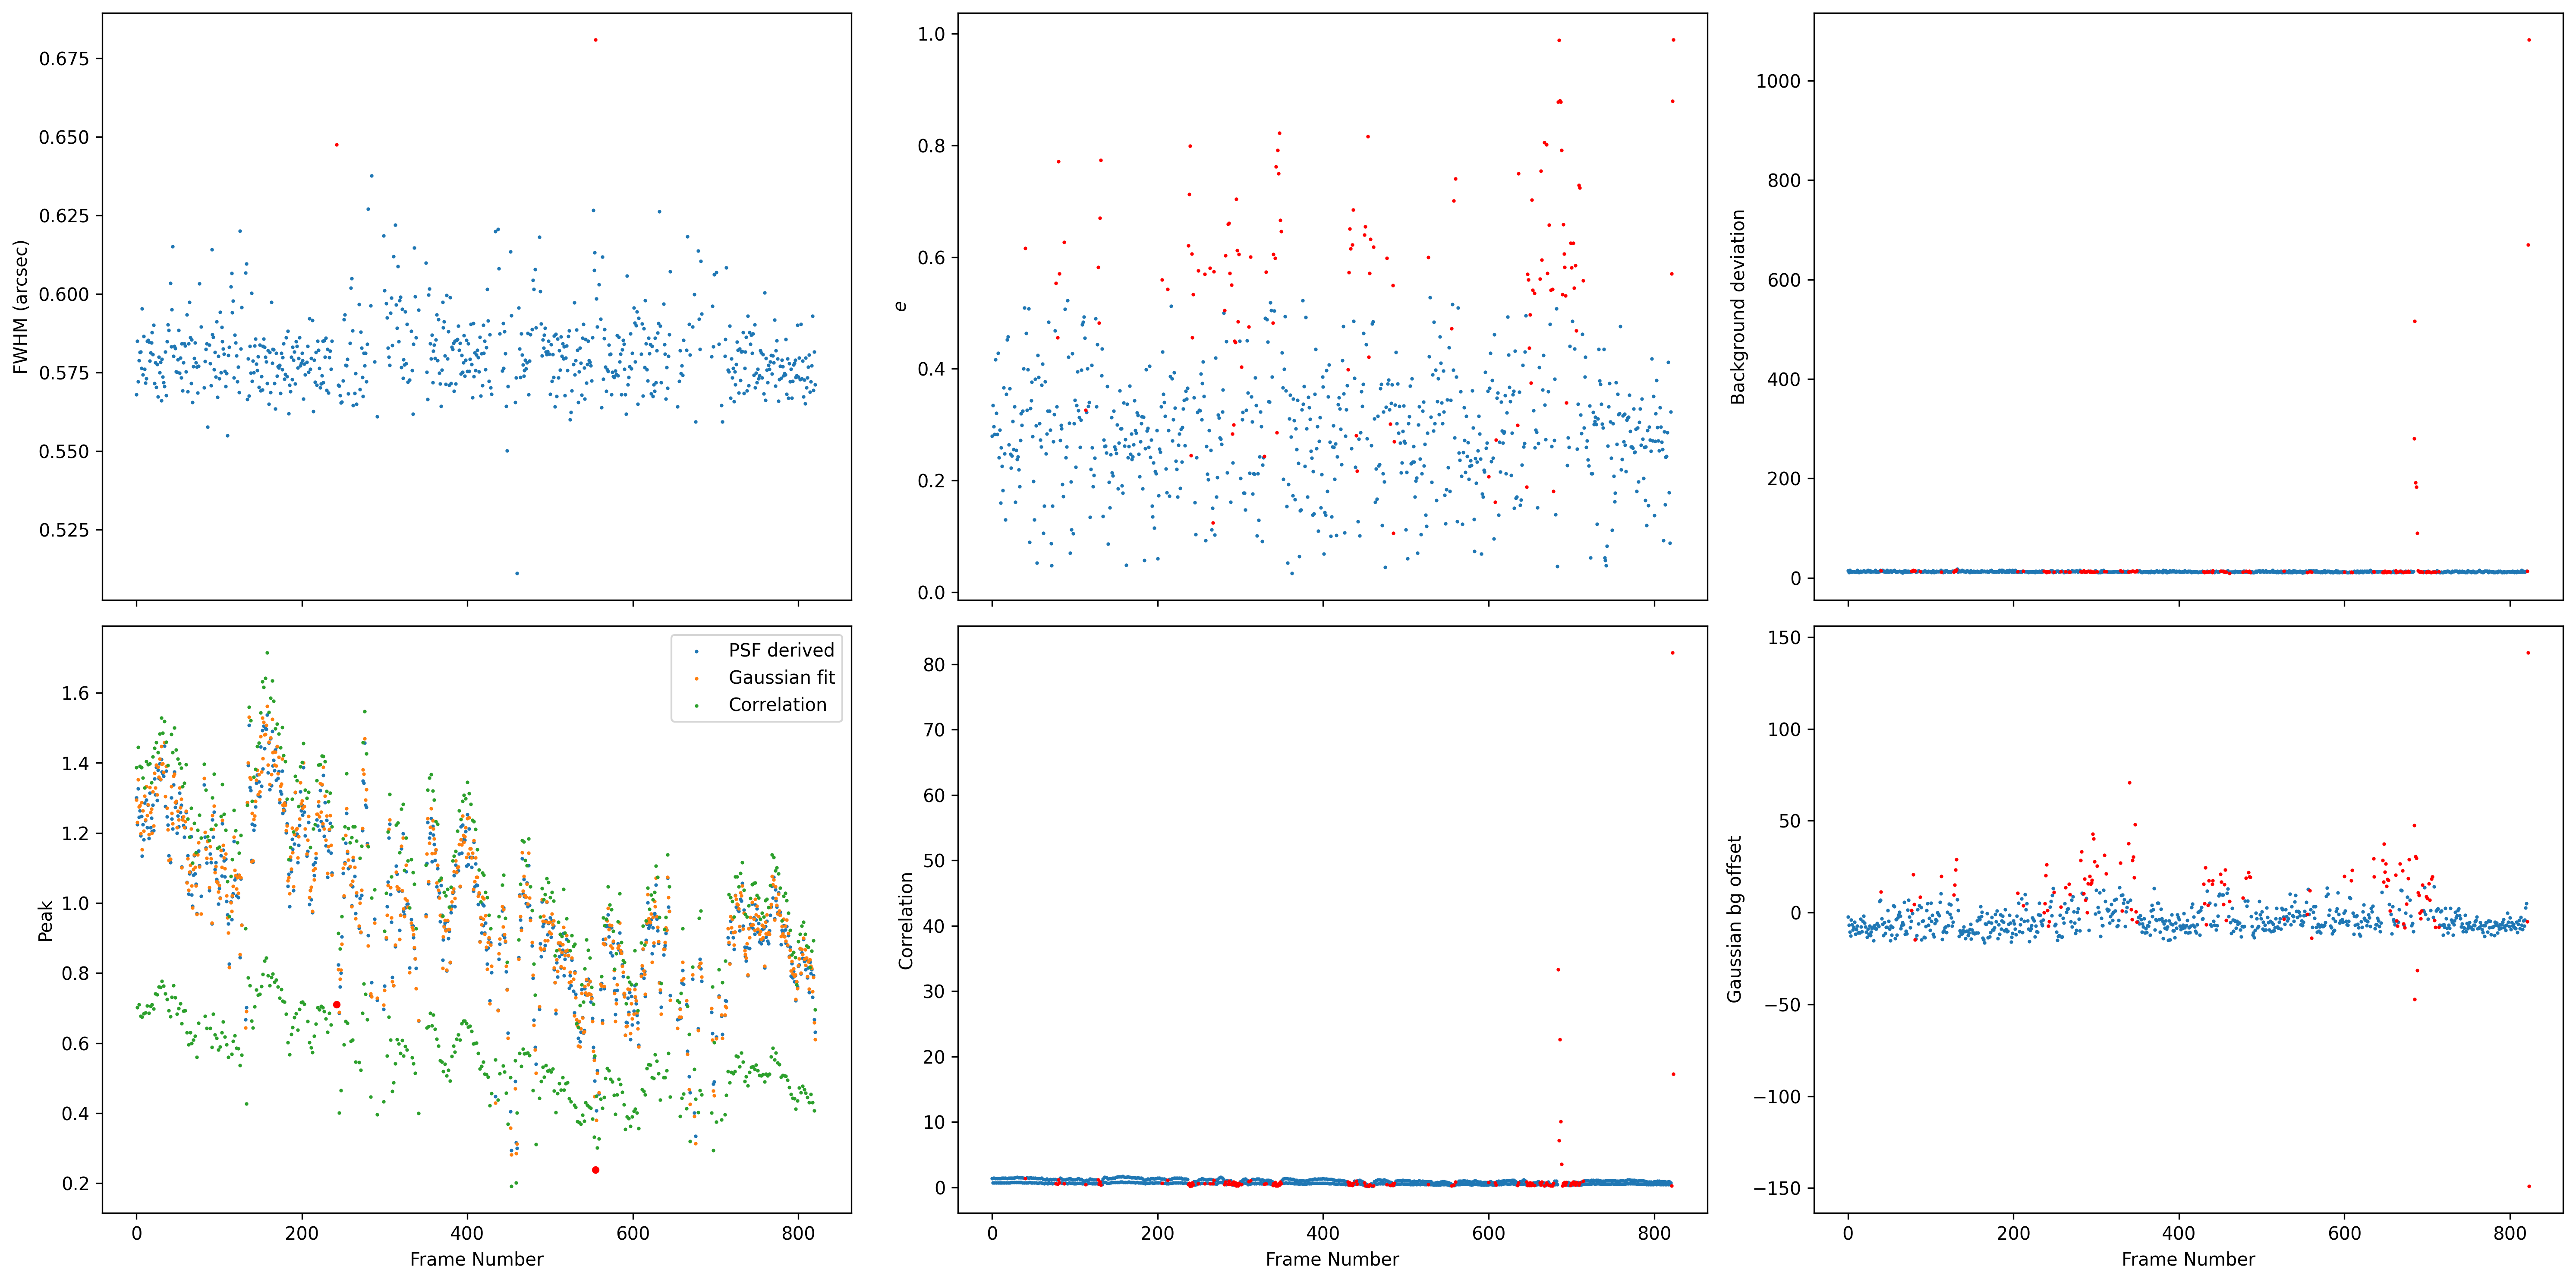

In [21]:
import matplotlib.pyplot as plt
xlist = np.linspace(0, len(fwhms)-1, len(fwhms))
fig, ax = plt.subplots(2, 3,figsize=(20,10), dpi=300, sharex=True)

ax[0,0].scatter(xlist[frame_bool], fwhms[frame_bool], s=1)
ax[0,0].scatter(xlist[frame_bool ^ fwhms_bool], fwhms[frame_bool ^ fwhms_bool], s=1, color="red")
ax[0,0].set_ylabel("FWHM (arcsec)")
ax[0,1].scatter(xlist[frame_bool], eccentricities[frame_bool], s=1)
ax[0,1].scatter(xlist[~frame_bool], eccentricities[~frame_bool], s=1, color="red")
ax[0,1].set_ylabel(r"$e$")
ax[0,2].scatter(xlist[frame_bool], background_dev[frame_bool], s=1)
ax[0,2].scatter(xlist[~frame_bool], background_dev[~frame_bool], s=1, color="red")
ax[0,2].set_ylabel("Background deviation")

ax[1,0].scatter(xlist[frame_bool], psfmaxima[frame_bool], s=1,label="PSF derived")
ax[1,0].set_ylabel("Peak")
ax[1,0].scatter(xlist[frame_bool], amplitudes[frame_bool], s=1, label="Gaussian fit")
ax[1,0].scatter(xlist[frame_bool], correlations[frame_bool], s=1, label="Correlation")
ax[1,0].scatter(xlist[frame_bool ^ fwhms_bool], correlations[frame_bool ^ fwhms_bool], s=10, color="red")
ax[1,0].legend(loc="best")
ax[1,0].set_xlabel("Frame Number")
ax[1,1].set_ylabel("Correlation")
ax[1,1].scatter(xlist[frame_bool], correlations[frame_bool], s=1)
ax[1,1].scatter(xlist[~frame_bool], correlations[~frame_bool], s=1, color="red")
ax[1,1].set_xlabel("Frame Number")
'''
ax[1,0].scatter(xlist[~frame_bool], psfmaxima[~frame_bool], s=10,label="PSF derived", marker="1", color="tab:blue")
ax[1,0].scatter(xlist[~frame_bool], amplitudes[~frame_bool], s=10, label="Gaussian fit",marker="1", color="tab:orange")
ax[1,0].scatter(xlist[~frame_bool], correlations[~frame_bool], s=10, label="Correlation",marker="1", color="tab:green")
'''
ax[1,2].scatter(xlist[frame_bool], gauss_offsets[frame_bool], s=1)
ax[1,2].scatter(xlist[~frame_bool], gauss_offsets[~frame_bool], s=1, color="red")
ax[1,2].set_ylabel("Gaussian bg offset")
ax[1,2].set_xlabel("Frame Number")

plt.tight_layout()
plt.show()